# 01 — LFW dataset exploration

**Goal:** verify that LFW funneled images and supplied pairs are ready for a face-verification baseline.

This notebook downloads data, measures dataset properties, displays development pairs, and saves a summary and an identity-distribution plot. It does not compute recognition accuracy.

Run cells from top to bottom. The first download is about 232 MiB; allow at least 1 GB of free disk space. Cached files are verified and reused on later runs. Record your own observations at the end.


In [1]:
from pathlib import Path
import sys
import json

# Works when Jupyter starts from the repository root or its notebooks folder.
ROOT = next((p for p in (Path.cwd(), *Path.cwd().parents)
             if (p / 'src' / 'lfw_dataset.py').is_file()), None)
if ROOT is None:
    raise RuntimeError('Open Jupyter from inside biometrics-project1.')
sys.path.insert(0, str(ROOT / 'src'))
from lfw_dataset import download_lfw, inspect_lfw
print('Project:', ROOT)
print('Python:', sys.executable)


Project: /Users/dhrumil/Fall 2026/Biometrics/Evaluating Face Verification
Python: /Users/dhrumil/Fall 2026/Biometrics/Evaluating Face Verification/.venv/bin/python


## 1. Download and verify inputs
The URLs and expected SHA-256 checksums are recorded in `src/lfw_dataset.py`, using the metadata published by scikit-learn. Download failures stop execution; no success is assumed. Each successful download is recorded locally in `data/lfw_home/download_manifest.json`.


In [2]:
DATA_HOME = download_lfw(ROOT)
IMAGE_ROOT = DATA_HOME / 'lfw_funneled'


  25 MiB received


  50 MiB received


  75 MiB received


  100 MiB received


  125 MiB received


...

Verified lfw-funneled.tgz


Verified pairsDevTrain.txt


Verified pairsDevTest.txt


Verified pairs.txt


Extracting verified archive ...


## 2. Inspect images and verification pairs
The code decodes all JPEGs one at a time, measures dimensions and source color modes, and validates every pair path. It retains the supplied pair order and evaluation folds.

Published expectations are 13,233 images and 5,749 identities. They are checked against measured counts. The JSON output includes actual counts, dependency versions, source checksums, and the current Git commit. Failures stop the notebook and must be investigated.


In [3]:
summary, identity_counts, pair_sets = inspect_lfw(ROOT)


Inspected 3000/13233 images


Inspected 6000/13233 images


Inspected 9000/13233 images


Inspected 12000/13233 images


{
  "image_count": 13233,
  "identity_count": 5749,
  "dimensions": {
    "250x250": 13233
  },
  "color_modes": {
    "RGB": 13233
  },
  "pairs": {
    "pairsDevTrain.txt": {
      "total": 2200,
      "same": 1100,
      "different": 1100,
      "folds": 1
    },
    "pairsDevTest.txt": {
      "total": 1000,
      "same": 500,
      "different": 500,
      "folds": 1
    },
    "pairs.txt": {
      "total": 6000,
      "same": 3000,
      "different": 3000,
      "folds": 10
    }
  },
  "checks": {
    "expected_image_count": true,
    "expected_identity_count": true,
    "all_images_250x250": true,
    "all_images_readable": true,
    "all_pair_paths_exist": true
  },
  "all_checks_passed": true
}
Saved results/metrics/dataset_summary.json


## 3. Explore the number of images per identity
This plot uses all image counts, but no recognition scores. Logarithmic axes make the uneven distribution easier to see. We do not filter out people with only one image: supplied different-person pairs can still use them.


Matplotlib is building the font cache; this may take a moment.


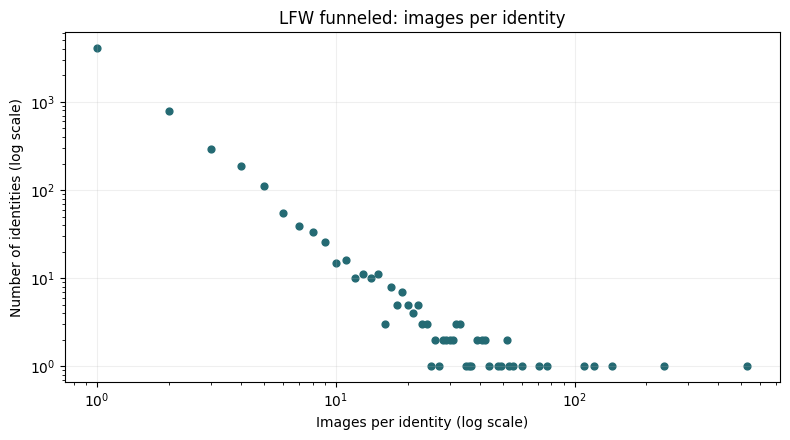

Saved results/figures/lfw_identity_distribution.png
People with at least two images: 1680
Minimum images per identity: 1
Maximum images per identity: 530


In [4]:
from collections import Counter
import matplotlib.pyplot as plt

frequency = Counter(identity_counts.values())
x = sorted(frequency)
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.scatter(x, [frequency[n] for n in x], s=24, color='#246a73')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Images per identity (log scale)')
ax.set_ylabel('Number of identities (log scale)')
ax.set_title('LFW funneled: images per identity')
ax.grid(alpha=0.2)
fig.tight_layout()
figure_dir = ROOT / 'results' / 'figures'
figure_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(figure_dir / 'lfw_identity_distribution.png', dpi=160)
plt.show()
print('Saved results/figures/lfw_identity_distribution.png')
print('People with at least two images:', summary['identities_with_two_or_more_images'])
print('Minimum images per identity:', summary['images_per_identity_min'])
print('Maximum images per identity:', summary['images_per_identity_max'])


## 4. Display development pairs
Show the first two same-person and first two different-person development-training pairs. Labels come from the supplied protocol. These examples are illustrative, not a random sample or evidence of model performance.

Source images are left unchanged. Conversion to RGB below is only for consistent display; dimensions remain 250 × 250. No face detection, cropping, alignment, normalization, or degradation is applied here.


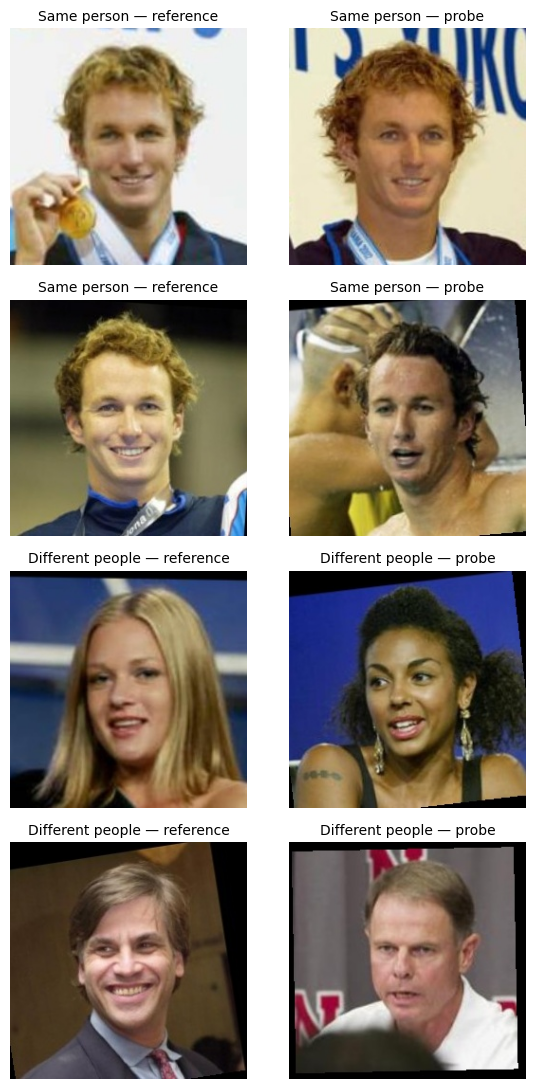

In [5]:
from PIL import Image

train_pairs = pair_sets['pairsDevTrain.txt']
examples = ([p for p in train_pairs if p['label'] == 1][:2]
            + [p for p in train_pairs if p['label'] == 0][:2])
fig, axes = plt.subplots(len(examples), 2, figsize=(6, 11))
for row, pair in enumerate(examples):
    label = 'Same person' if pair['label'] else 'Different people'
    for col, role in enumerate(('reference', 'probe')):
        with Image.open(IMAGE_ROOT / pair[role]) as picture:
            axes[row, col].imshow(picture.convert('RGB'))
        axes[row, col].set_title(f'{label} — {role}', fontsize=10)
        axes[row, col].axis('off')
fig.tight_layout()
plt.show()


## 5. Recorded observations

- **Date run:** 2026-09-08, America/New_York; validation timestamp `2026-09-09T02:41:47.735201+00:00` (UTC).
- **Validation:** all checks passed. The run measured 13,233 images across 5,749 identities; all decoded as 250 x 250 RGB images. No unreadable images or missing pair references were found. Pair totals were 2,200 development-training, 1,000 development-testing, and 6,000 evaluation pairs in 10 folds, with the required class balance and ordering.
- **Images per identity:** the distribution is strongly uneven. There are 4,069 single-image identities (70.8%) and 1,680 with at least two images. Counts range from 1 to 530. The logarithmic plot shows many identities with few images and a small number with hundreds. We retained the supplied pairs and did not filter identities.
- **Displayed examples:** the two same-person development examples show changes in expression, lighting, background, and slight head angle. Across the four displayed pairs, apparent sharpness varies and some images have black or rotated borders from alignment. These observations describe only the displayed examples; they are not a dataset-wide quality assessment or recognition result.
- **Installation and download:** the supplied Pillow, matplotlib, JupyterLab, and ipykernel pins installed successfully in the local Python 3.13.7 environment. The first download failed with `CERTIFICATE_VERIFY_FAILED: unable to get local issuer certificate`; Python's default CA file and directory were absent. The downloader was updated to supplement default trust roots with the pinned certifi CA bundle. The rerun downloaded all four files and matched every published SHA-256 checksum. TLS verification stayed enabled. No HTTP 403 occurred on this Mac.
- **Readiness:** the downloaded inputs and pair protocol are ready for baseline implementation. Model selection, training-data overlap review, face preprocessing, and embedding generation still need to be completed and checked.

**Scope:** this stage validates input data only. We have not measured face-verification accuracy, FMR, or FNMR.


## 6. Generate a factual log entry
Run this after the earlier cells succeed. Copy the printed entry into the existing `docs/experiment_log.md`, then add your observations and any problems. This cell prints a draft; it does not change your log or create a Git commit.


In [6]:
if not summary['all_checks_passed']:
    raise RuntimeError('Resolve validation failures before recording success.')
entry = f"""
## Stage 003 — LFW Download and Exploration

### Run time (UTC)
{summary['run_at_utc']}

### Goal
Download LFW funneled images and validate them for the baseline.

### Changes
Added checksum-verified downloading, pair parsing, image inspection,
and a Jupyter exploration notebook.

### Measured Results
- Images: {summary['image_count']}
- Identities: {summary['identity_count']}
- Image dimensions: {summary['dimensions']}
- Source color modes: {summary['color_modes']}
- Identities with two or more images: {summary['identities_with_two_or_more_images']}
- Unreadable images: {len(summary['unreadable_images'])}
- Missing pair references: {len(summary['missing_pair_references'])}
- All dataset validation checks passed: {summary['all_checks_passed']}

### Saved Outputs
- results/metrics/dataset_summary.json
- results/figures/lfw_identity_distribution.png

### Observations and Problems
[Add your actual observations, errors, and fixes here.]

### Next Step
Select a pretrained model and test the face-preprocessing and embedding
pipeline on development images. No verification metrics exist yet.
"""
print(entry)



## Stage 003 — LFW Download and Exploration

### Run time (UTC)
2026-09-09T02:41:47.735201+00:00

### Goal
Download LFW funneled images and validate them for the baseline.

### Changes
Added checksum-verified downloading, pair parsing, image inspection,
and a Jupyter exploration notebook.

### Measured Results
- Images: 13233
- Identities: 5749
- Image dimensions: {'250x250': 13233}
- Source color modes: {'RGB': 13233}
- Identities with two or more images: 1680
- Unreadable images: 0
- Missing pair references: 0
- All dataset validation checks passed: True

### Saved Outputs
- results/metrics/dataset_summary.json
- results/figures/lfw_identity_distribution.png

### Observations and Problems
[Add your actual observations, errors, and fixes here.]

### Next Step
Select a pretrained model and test the face-preprocessing and embedding
pipeline on development images. No verification metrics exist yet.



## References
- [LFW technical report](https://people.cs.umass.edu/~elm/papers/lfw.pdf)
- [scikit-learn download metadata](https://github.com/scikit-learn/scikit-learn/blob/main/sklearn/datasets/_lfw.py)
- [Funneled archive mirror](https://figshare.com/articles/dataset/lfw-funneled_tgz/3829980)

Use the dataset according to the source notices. Do not commit downloaded images to Git.
